In [29]:
print("fresh kernel check")
import sys
print('nets' in sys.modules)

fresh kernel check
True


In [30]:
!git clone https://github.com/Shiaoming/ALIKED.git

fatal: destination path 'ALIKED' already exists and is not an empty directory.


In [31]:
import os
print(os.listdir('/content/ALIKED'))

['nets', 'LICENSE', 'requirements.txt', 'count_flops.py', 'ALIKED', 'custom_ops_disabled', 'assets', '.git', 'README.md', 'demo_seq.py', '.gitignore', 'models', 'demo_pair.py']


In [32]:
import os
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [33]:
import sys
sys.path.insert(0, '/content/ALIKED')
os.chdir('/content/ALIKED')

from nets.aliked import ALIKED
print("ALIKED imported successfully")

ALIKED imported successfully


In [34]:
!pip install -q torch torchvision --index-url https://download.pytorch.org/whl/cu121
!pip install -q opencv-python-headless matplotlib numpy

In [35]:
with open('/content/ALIKED/nets/__init__.py', 'w') as f:
    pass

print("Created:", os.path.exists('/content/ALIKED/nets/__init__.py'))

Created: True


In [36]:
import sys
sys.path.insert(0, '/content/ALIKED')
os.chdir('/content/ALIKED')

from nets.aliked import ALIKED
print("ALIKED imported successfully")

ALIKED imported successfully


In [37]:
from nets.aliked import ALIKED
print("ALIKED imported successfully")

ALIKED imported successfully


In [38]:
import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Using device:", device)

model = ALIKED(model_name='aliked-n16', device=device, top_k=-1, scores_th=0.2, n_limit=5000)
model.eval()
print("Model loaded")

Using device: cuda
loading /content/ALIKED/models/aliked-n16.pth
Model loaded


In [40]:
dataset_dir = '/content/drive/MyDrive/rgb'

files = sorted(os.listdir(dataset_dir))
print(f"Total images: {len(files)}")
print(files[:5])

Total images: 613
['1305031452.791720.png', '1305031452.823674.png', '1305031452.859642.png', '1305031452.891726.png', '1305031452.923715.png']


In [41]:
import cv2

img1_path = os.path.join(dataset_dir, files[0])
img2_path = os.path.join(dataset_dir, files[1])

img1_bgr = cv2.imread(img1_path)
img1_rgb = cv2.cvtColor(img1_bgr, cv2.COLOR_BGR2RGB)

img2_bgr = cv2.imread(img2_path)
img2_rgb = cv2.cvtColor(img2_bgr, cv2.COLOR_BGR2RGB)

print("Image 1 shape:", img1_rgb.shape)
print("Image 2 shape:", img2_rgb.shape)

Image 1 shape: (480, 640, 3)
Image 2 shape: (480, 640, 3)


In [42]:
with torch.no_grad():
    out1 = model.run(img1_rgb)
    out2 = model.run(img2_rgb)

print("Image 1 keypoints:", len(out1['keypoints']))
print("Image 2 keypoints:", len(out2['keypoints']))

Image 1 keypoints: 380
Image 2 keypoints: 509


In [43]:
desc1 = out1['descriptors']
desc2 = out2['descriptors']

if not torch.is_tensor(desc1):
    desc1 = torch.tensor(desc1)
if not torch.is_tensor(desc2):
    desc2 = torch.tensor(desc2)

sim = desc1 @ desc2.T
nn_sim, nn_idx = sim.max(dim=1)

print("Number of raw matches:", len(nn_idx))
print("Sample similarity scores:", nn_sim[:5])

Number of raw matches: 380
Sample similarity scores: tensor([0.9171, 0.9367, 0.9278, 0.7904, 0.5946])


In [44]:
import numpy as np

kpts1 = out1['keypoints']
kpts2 = out2['keypoints']

if torch.is_tensor(kpts1):
    kpts1 = kpts1.cpu().numpy()
if torch.is_tensor(kpts2):
    kpts2 = kpts2.cpu().numpy()

pts1 = kpts1
pts2 = kpts2[nn_idx.cpu().numpy()]

F, mask = cv2.findFundamentalMat(pts1, pts2, cv2.FM_RANSAC, ransacReprojThreshold=1.0, confidence=0.99)

inliers = int(mask.sum()) if mask is not None else 0
total_matches = len(pts1)
inlier_ratio = inliers / total_matches if total_matches > 0 else 0

print("Matches:", total_matches)
print("Inliers:", inliers)
print("Inlier ratio: {:.2%}".format(inlier_ratio))

Matches: 380
Inliers: 231
Inlier ratio: 60.79%


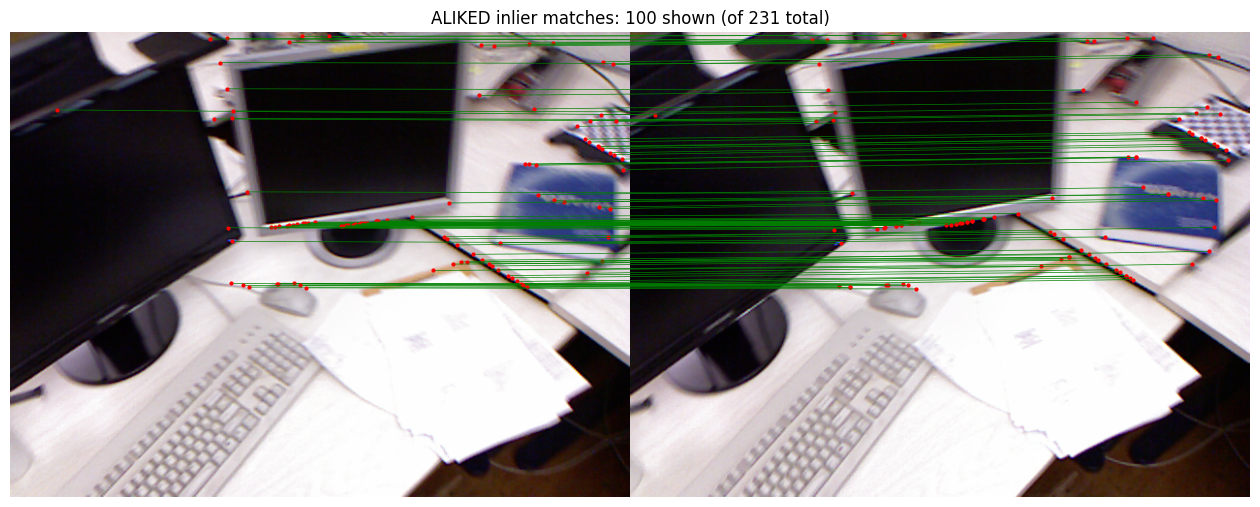

In [45]:
import matplotlib.pyplot as plt

h1, w1 = img1_rgb.shape[:2]
h2, w2 = img2_rgb.shape[:2]
canvas = np.zeros((max(h1, h2), w1 + w2, 3), dtype=np.uint8)
canvas[:h1, :w1] = img1_rgb
canvas[:h2, w1:w1+w2] = img2_rgb

inlier_idx = np.where(mask.ravel() == 1)[0]
draw_idx = inlier_idx[:100]  # limit for clarity

plt.figure(figsize=(16, 8))
plt.imshow(canvas)
for idx in draw_idx:
    x1, y1 = pts1[idx]
    x2, y2 = pts2[idx]
    plt.plot([x1, x2 + w1], [y1, y2], 'g-', linewidth=0.5)
    plt.plot(x1, y1, 'ro', markersize=2)
    plt.plot(x2 + w1, y2, 'ro', markersize=2)
plt.title(f"ALIKED inlier matches: {len(draw_idx)} shown (of {inliers} total)")
plt.axis('off')
plt.show()

In [46]:
import csv
import time

results = []
start_time = time.time()

for i in range(len(files) - 1):
    img1_path = os.path.join(dataset_dir, files[i])
    img2_path = os.path.join(dataset_dir, files[i+1])

    img1_bgr = cv2.imread(img1_path)
    img1_rgb = cv2.cvtColor(img1_bgr, cv2.COLOR_BGR2RGB)
    img2_bgr = cv2.imread(img2_path)
    img2_rgb = cv2.cvtColor(img2_bgr, cv2.COLOR_BGR2RGB)

    with torch.no_grad():
        out1 = model.run(img1_rgb)
        out2 = model.run(img2_rgb)

    kpts1 = out1['keypoints']
    kpts2 = out2['keypoints']
    desc1 = out1['descriptors']
    desc2 = out2['descriptors']

    if torch.is_tensor(kpts1): kpts1 = kpts1.cpu().numpy()
    if torch.is_tensor(kpts2): kpts2 = kpts2.cpu().numpy()
    if not torch.is_tensor(desc1): desc1 = torch.tensor(desc1)
    if not torch.is_tensor(desc2): desc2 = torch.tensor(desc2)

    sim = desc1 @ desc2.T
    nn_sim, nn_idx = sim.max(dim=1)
    nn_idx_np = nn_idx.cpu().numpy()

    pts1 = kpts1
    pts2 = kpts2[nn_idx_np]

    num_matches = len(pts1)

    if num_matches >= 8:
        F, mask = cv2.findFundamentalMat(pts1, pts2, cv2.FM_RANSAC, ransacReprojThreshold=1.0, confidence=0.99)
        num_inliers = int(mask.sum()) if mask is not None else 0
    else:
        num_inliers = 0

    inlier_ratio = num_inliers / num_matches if num_matches > 0 else 0

    results.append({
        'pair_index': i,
        'frame1': files[i],
        'frame2': files[i+1],
        'num_keypoints1': len(kpts1),
        'num_keypoints2': len(kpts2),
        'num_matches': num_matches,
        'num_inliers': num_inliers,
        'inlier_ratio': inlier_ratio
    })

    if i % 50 == 0:
        elapsed = time.time() - start_time
        print(f"Pair {i}/{len(files)-1} done | elapsed: {elapsed:.1f}s")

print("Batch run complete. Total time: {:.1f}s".format(time.time() - start_time))

Pair 0/612 done | elapsed: 0.1s
Pair 50/612 done | elapsed: 22.7s
Pair 100/612 done | elapsed: 26.2s
Pair 150/612 done | elapsed: 29.9s
Pair 200/612 done | elapsed: 33.3s
Pair 250/612 done | elapsed: 36.3s
Pair 300/612 done | elapsed: 39.6s
Pair 350/612 done | elapsed: 43.3s
Pair 400/612 done | elapsed: 46.7s
Pair 450/612 done | elapsed: 49.9s
Pair 500/612 done | elapsed: 53.1s
Pair 550/612 done | elapsed: 56.4s
Pair 600/612 done | elapsed: 59.9s
Batch run complete. Total time: 60.6s


In [47]:
import pandas as pd

df = pd.DataFrame(results)
csv_path = '/content/drive/MyDrive/aliked_consecutive_pairs.csv'
df.to_csv(csv_path, index=False)

print("Saved to:", csv_path)
print(df.head())
print()
print("Summary stats:")
print(df[['num_matches', 'num_inliers', 'inlier_ratio']].describe())

Saved to: /content/drive/MyDrive/aliked_consecutive_pairs.csv
   pair_index                 frame1                 frame2  num_keypoints1  \
0           0  1305031452.791720.png  1305031452.823674.png             380   
1           1  1305031452.823674.png  1305031452.859642.png             509   
2           2  1305031452.859642.png  1305031452.891726.png             579   
3           3  1305031452.891726.png  1305031452.923715.png             476   
4           4  1305031452.923715.png  1305031452.959701.png             602   

   num_keypoints2  num_matches  num_inliers  inlier_ratio  
0             509          380          231      0.607895  
1             579          509          343      0.673870  
2             476          579          361      0.623489  
3             602          476          324      0.680672  
4             603          602          423      0.702658  

Summary stats:
       num_matches  num_inliers  inlier_ratio
count   612.000000   612.000000    612.00

In [48]:
robustness_dir = '/content/drive/MyDrive/assignment-3-dataset-low-texture-finding'
robustness_files = sorted(os.listdir(robustness_dir))
print(robustness_files)

['90-rotated-wall.jpeg', 'portrait-trolley.jpeg', 'portrait-wall.jpeg', 'trolley-45-rotated.jpeg', 'zoomed-trolley.jpeg', 'zoomed-wall.jpeg']


In [50]:
import cv2

robustness_dir = '/content/drive/MyDrive/assignment-3-dataset-low-texture-finding'

def load_rgb(filename):
    path = os.path.join(robustness_dir, filename)
    img_bgr = cv2.imread(path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    return img_rgb

portrait_trolley = load_rgb('portrait-trolley.jpeg')
trolley_45_rotated = load_rgb('trolley-45-rotated.jpeg')
zoomed_trolley = load_rgb('zoomed-trolley.jpeg')

portrait_wall = load_rgb('portrait-wall.jpeg')
rotated_90_wall = load_rgb('90-rotated-wall.jpeg')
zoomed_wall = load_rgb('zoomed-wall.jpeg')

print("All images loaded with original names")

All images loaded with original names


In [53]:
def run_aliked_test(img1_rgb, img2_rgb, label):
    with torch.no_grad():
        out1 = model.run(img1_rgb)
        out2 = model.run(img2_rgb)

    kpts1 = out1['keypoints']
    kpts2 = out2['keypoints']
    desc1 = out1['descriptors']
    desc2 = out2['descriptors']

    if torch.is_tensor(kpts1): kpts1 = kpts1.cpu().numpy()
    if torch.is_tensor(kpts2): kpts2 = kpts2.cpu().numpy()
    if not torch.is_tensor(desc1): desc1 = torch.tensor(desc1)
    if not torch.is_tensor(desc2): desc2 = torch.tensor(desc2)

    sim = desc1 @ desc2.T
    nn_sim, nn_idx = sim.max(dim=1)
    nn_idx_np = nn_idx.cpu().numpy()

    pts1 = kpts1
    pts2 = kpts2[nn_idx_np]

    num_matches = len(pts1)

    if num_matches >= 8:
        F, mask = cv2.findFundamentalMat(pts1, pts2, cv2.FM_RANSAC, ransacReprojThreshold=1.0, confidence=0.99)
        num_inliers = int(mask.sum()) if mask is not None else 0
    else:
        num_inliers = 0

    inlier_ratio = num_inliers / num_matches if num_matches > 0 else 0

    print(f"--- {label} ---")
    print(f"Keypoints img1: {len(kpts1)} | Keypoints img2: {len(kpts2)}")
    print(f"Matches: {num_matches} | Inliers: {num_inliers} | Inlier ratio: {inlier_ratio:.2%}")
    print()

    return {
        'test': label,
        'kpts1': len(kpts1),
        'kpts2': len(kpts2),
        'matches': num_matches,
        'inliers': num_inliers,
        'inlier_ratio': inlier_ratio
    }

In [55]:
def load_rgb(filename, max_dim=1280):
    path = os.path.join(robustness_dir, filename)
    img_bgr = cv2.imread(path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    h, w = img_rgb.shape[:2]
    scale = max_dim / max(h, w)
    if scale < 1:
        new_w, new_h = int(w * scale), int(h * scale)
        img_rgb = cv2.resize(img_rgb, (new_w, new_h), interpolation=cv2.INTER_AREA)

    return img_rgb

portrait_trolley = load_rgb('portrait-trolley.jpeg')
trolley_45_rotated = load_rgb('trolley-45-rotated.jpeg')
zoomed_trolley = load_rgb('zoomed-trolley.jpeg')

portrait_wall = load_rgb('portrait-wall.jpeg')
rotated_90_wall = load_rgb('90-rotated-wall.jpeg')
zoomed_wall = load_rgb('zoomed-wall.jpeg')

print("All images reloaded and resized")
print("portrait_trolley:", portrait_trolley.shape)
print("trolley_45_rotated:", trolley_45_rotated.shape)
print("zoomed_trolley:", zoomed_trolley.shape)
print("portrait_wall:", portrait_wall.shape)
print("rotated_90_wall:", rotated_90_wall.shape)
print("zoomed_wall:", zoomed_wall.shape)

All images reloaded and resized
portrait_trolley: (1280, 960, 3)
trolley_45_rotated: (1280, 960, 3)
zoomed_trolley: (1280, 960, 3)
portrait_wall: (1280, 960, 3)
rotated_90_wall: (960, 1280, 3)
zoomed_wall: (1280, 960, 3)


In [58]:
import gc
gc.collect()
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

print(torch.cuda.memory_allocated() / 1e9, "GB allocated")
print(torch.cuda.memory_reserved() / 1e9, "GB reserved")

1.35096064 GB allocated
2.759852032 GB reserved


In [59]:
robustness_results = []

robustness_results.append(run_aliked_test(portrait_trolley, trolley_45_rotated, "portrait-trolley vs trolley-45-rotated"))
robustness_results.append(run_aliked_test(portrait_trolley, zoomed_trolley, "portrait-trolley vs zoomed-trolley"))
robustness_results.append(run_aliked_test(portrait_wall, rotated_90_wall, "portrait-wall vs 90-rotated-wall"))
robustness_results.append(run_aliked_test(portrait_wall, zoomed_wall, "portrait-wall vs zoomed-wall"))

--- portrait-trolley vs trolley-45-rotated ---
Keypoints img1: 2686 | Keypoints img2: 3288
Matches: 2686 | Inliers: 490 | Inlier ratio: 18.24%

--- portrait-trolley vs zoomed-trolley ---
Keypoints img1: 2686 | Keypoints img2: 2862
Matches: 2686 | Inliers: 494 | Inlier ratio: 18.39%

--- portrait-wall vs 90-rotated-wall ---
Keypoints img1: 5000 | Keypoints img2: 2604
Matches: 5000 | Inliers: 1916 | Inlier ratio: 38.32%

--- portrait-wall vs zoomed-wall ---
Keypoints img1: 5000 | Keypoints img2: 3738
Matches: 5000 | Inliers: 1087 | Inlier ratio: 21.74%



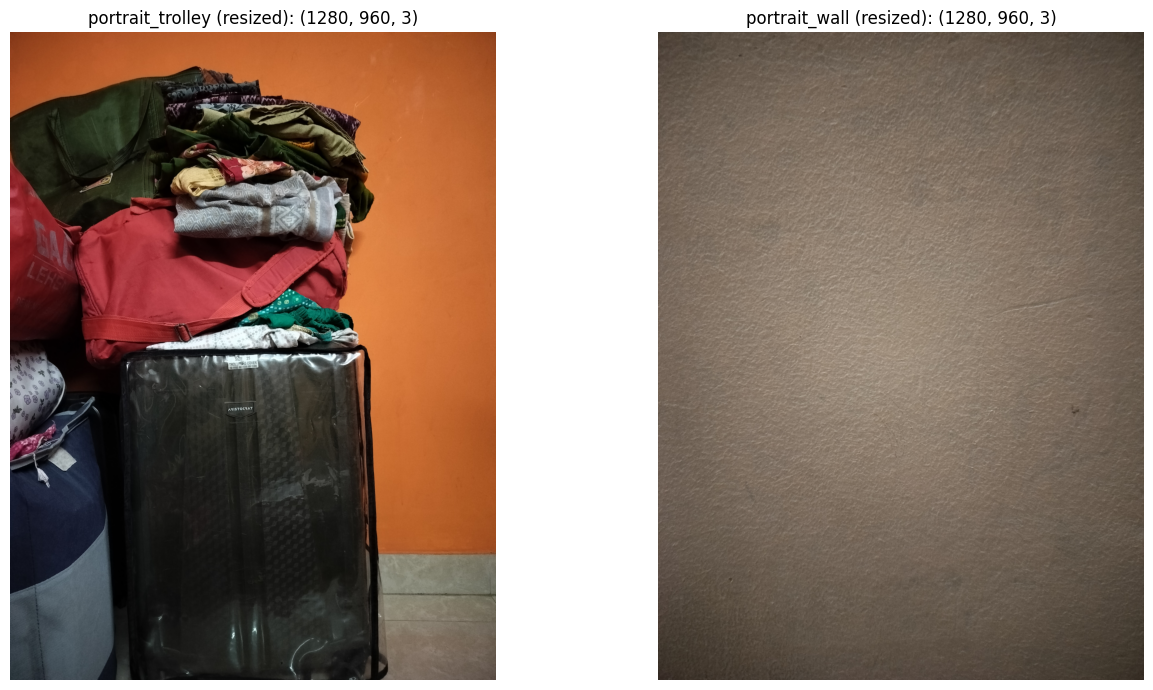

In [60]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
axes[0].imshow(portrait_trolley)
axes[0].set_title(f"portrait_trolley (resized): {portrait_trolley.shape}")
axes[0].axis('off')

axes[1].imshow(portrait_wall)
axes[1].set_title(f"portrait_wall (resized): {portrait_wall.shape}")
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [61]:
robustness_df = pd.DataFrame(robustness_results)
robustness_df.to_csv('/content/drive/MyDrive/aliked_robustness_tests.csv', index=False)
print(robustness_df)

                                     test  kpts1  kpts2  matches  inliers  \
0  portrait-trolley vs trolley-45-rotated   2686   3288     2686      490   
1      portrait-trolley vs zoomed-trolley   2686   2862     2686      494   
2        portrait-wall vs 90-rotated-wall   5000   2604     5000     1916   
3            portrait-wall vs zoomed-wall   5000   3738     5000     1087   

   inlier_ratio  
0      0.182427  
1      0.183917  
2      0.383200  
3      0.217400  
